In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


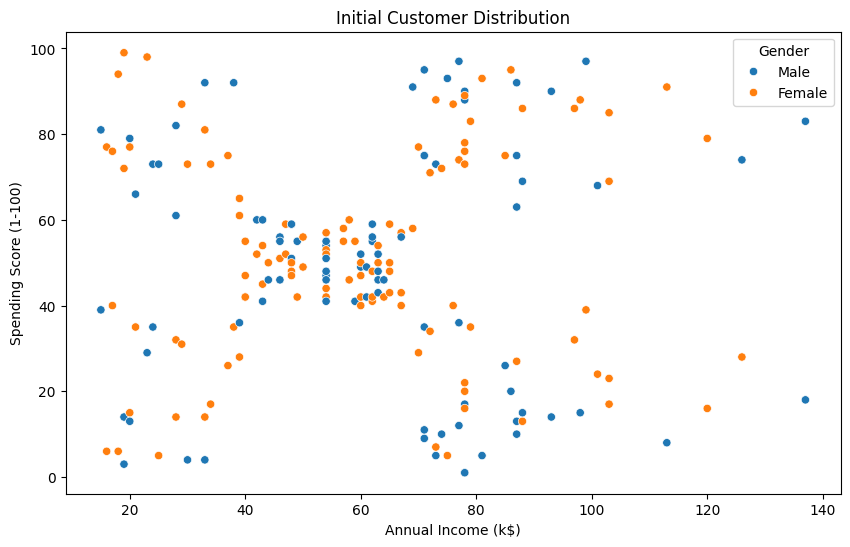

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title('Initial Customer Distribution')
plt.show()

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

In [8]:
best_k = max(scores, key=scores.get)
scare = scores[best_k]

print(f"The best Clusters: {best_k}")
print("Scare:", scare)

The best Clusters: 5
Scare: 0.5546571631111091


In [9]:
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

In [10]:
fig = px.scatter(df,
                 x='Annual Income (k$)',
                 y='Spending Score (1-100)',
                 color='Cluster',
                 size='Age',
                 hover_data=['Gender', 'Age'],
                 title=f'Final Segmentation (K={best_k})',
                 color_continuous_scale=px.colors.sequential.Viridis)

fig.update_layout(template='plotly_dark')
fig.show()

In [11]:
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2))

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        42.72               55.30                   49.52
1        32.69               86.54                   82.13
2        25.27               25.73                   79.36
3        41.11               88.20                   17.11
4        45.22               26.30                   20.91
